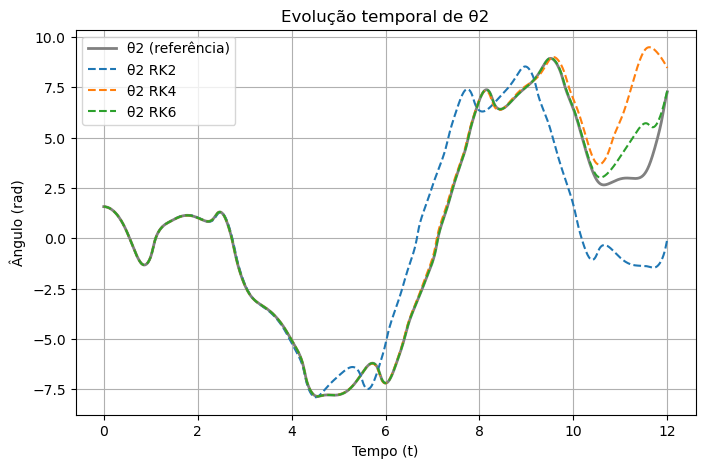

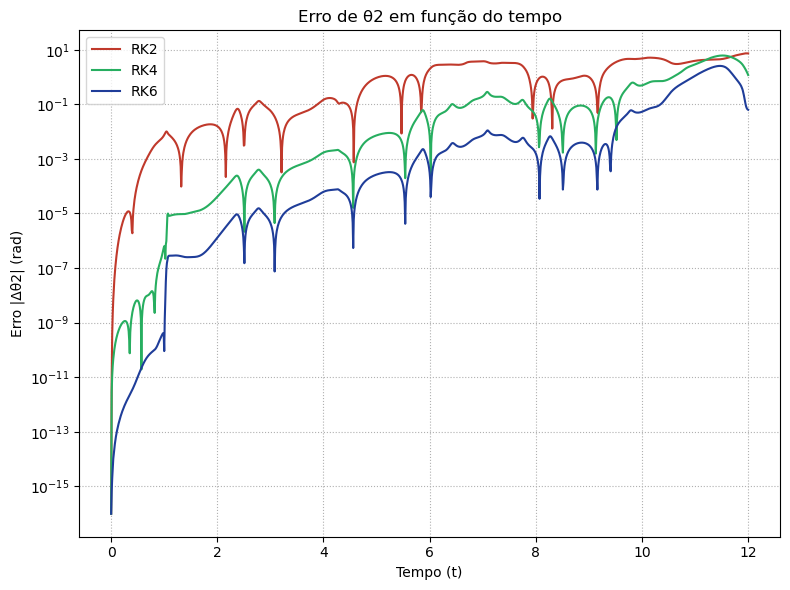

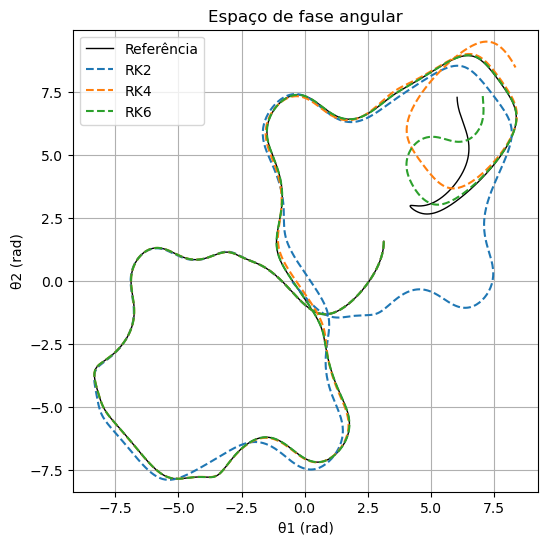

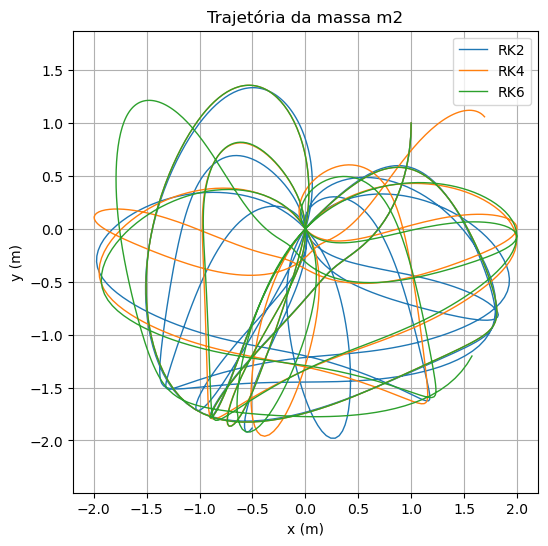

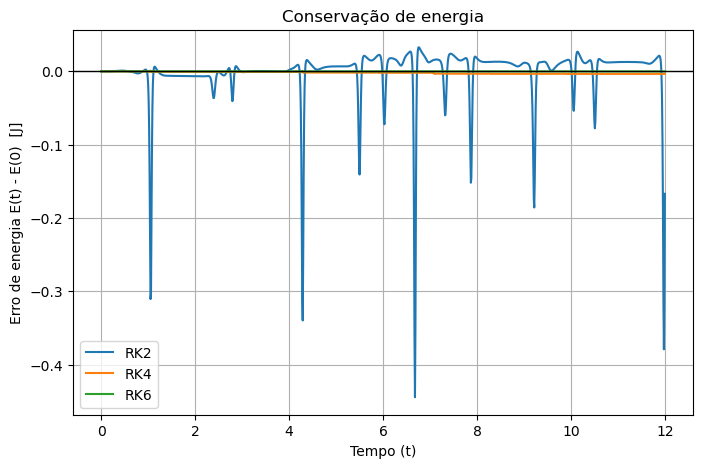

RK2: ordem de convergência (inclinação da reta) = 1.966
RK4: ordem de convergência (inclinação da reta) = 3.944
RK6: ordem de convergência (inclinação da reta) = 5.689


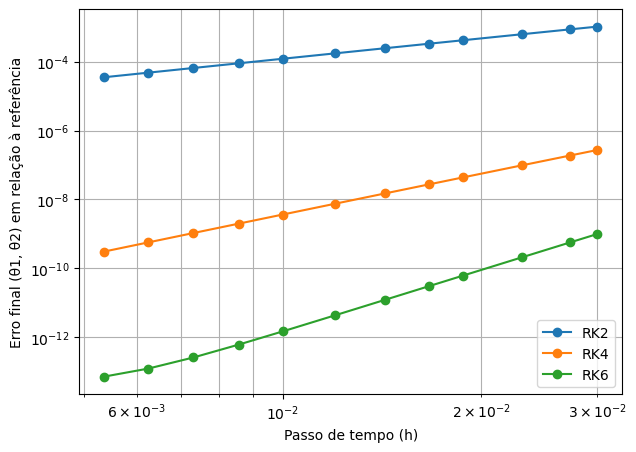

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline

# Parâmetros
m1, m2 = 1.0, 1.0      
l1, l2 = 1.0, 1.0     
g = 9.8                

# Condições iniciais: [theta1, omega1, theta2, omega2]
theta1_0, omega1_0 = np.pi/1, 0.0   
theta2_0, omega2_0 = np.pi/2, 0.0
y0 = np.array([theta1_0, omega1_0, theta2_0, omega2_0])

T = 12.0
h = 0.01

# Equações de movimento do pêndulo duplo
def deriv(t, y):
    th1, w1, th2, w2 = y
    delta = th1 - th2

    den1 = l1 * (2*m1 + m2 - m2*np.cos(2*th1 - 2*th2))
    dw1 = (-g*(2*m1 + m2)*np.sin(th1) - m2*g*np.sin(th1 - 2*th2) - 2*np.sin(delta)*m2*(w2**2*l2 + w1**2*l1*np.cos(delta))) / den1

    den2 = l2 * (2*m1 + m2 - m2*np.cos(2*th1 - 2*th2))
    dw2 = (2*np.sin(delta)*(w1**2*l1*(m1+m2) + g*(m1+m2)*np.cos(th1) + w2**2*l2*m2*np.cos(delta))) / den2

    return np.array([w1, dw1, w2, dw2])

# Passos dos métodos numéricos
def rk2_step(t, y, h):
    k1 = deriv(t, y)
    k2 = deriv(t + h, y + h * k1)
    return y + h * (k1 + k2) / 2

def rk4_step(t, y, h):
    k1 = deriv(t, y)
    k2 = deriv(t + h/2, y + h*k1/2)
    k3 = deriv(t + h/2, y + h*k2/2)
    k4 = deriv(t + h, y + h*k3)
    return y + h * (k1 + 2*k2 + 2*k3 + k4) / 6

# RK6: método de Luther (1968), 7 estágios, ordem 6
_q = np.sqrt(21)

def rk6_step(t, y, h):
    c2, c3, c4 = 1.0, 0.5, 2/3
    c5, c6, c7 = (7 - _q)/14, (7 + _q)/14, 1.0

    a21 = 1.0
    a31, a32 = 3/8, 1/8
    a41, a42, a43 = 8/27, 2/27, 8/27
    a51 = (-21 + 9*_q)/392
    a52 = (-56 + 8*_q)/392
    a53 = (336 - 48*_q)/392
    a54 = (-63 + 3*_q)/392
    a61 = (-1155 - 255*_q)/1960
    a62 = (-280 - 40*_q)/1960
    a63 = (-320*_q)/1960
    a64 = (63 + 363*_q)/1960
    a65 = (2352 + 392*_q)/1960
    a71 = (330 + 105*_q)/180
    a72 = 2/3
    a73 = (-200 + 280*_q)/180
    a74 = (126 - 189*_q)/180
    a75 = (-686 - 126*_q)/180
    a76 = (490 - 70*_q)/180

    b1, b3, b5, b6, b7 = 1/20, 16/45, 49/180, 49/180, 1/20

    k1 = deriv(t, y)
    k2 = deriv(t + c2*h, y + h*a21*k1)
    k3 = deriv(t + c3*h, y + h*(a31*k1 + a32*k2))
    k4 = deriv(t + c4*h, y + h*(a41*k1 + a42*k2 + a43*k3))
    k5 = deriv(t + c5*h, y + h*(a51*k1 + a52*k2 + a53*k3 + a54*k4))
    k6 = deriv(t + c6*h, y + h*(a61*k1 + a62*k2 + a63*k3 + a64*k4 + a65*k5))
    k7 = deriv(t + c7*h, y + h*(a71*k1 + a72*k2 + a73*k3 + a74*k4 + a75*k5 + a76*k6))

    return y + h*(b1*k1 + b3*k3 + b5*k5 + b6*k6 + b7*k7)

# Função de integração
def integrar(metodo, y0, T, h):
    
    n_steps = int(round(T / h))
    t_vals = np.zeros(n_steps + 1)
    y_vals = np.zeros((n_steps + 1, len(y0)))
    t_vals[0] = 0.0
    y_vals[0] = y0

    for i in range(n_steps):
        t_vals[i+1] = t_vals[i] + h
        y_vals[i+1] = metodo(t_vals[i], y_vals[i], h)

    return t_vals, y_vals

# Converte ângulos em posições cartesianas das duas massas
def posicoes(y):
    th1, th2 = y[:, 0], y[:, 2]
    x1 = l1*np.sin(th1)
    y1 = -l1*np.cos(th1)
    x2 = x1 + l2*np.sin(th2)
    y2 = y1 - l2*np.cos(th2)
    return x1, y1, x2, y2

# Energia mecânica total
def energia(y):
    th1, w1, th2, w2 = y[:, 0], y[:, 1], y[:, 2], y[:, 3]
    Ecin = 0.5*m1*l1**2*w1**2 + 0.5*m2*(l1**2*w1**2 + l2**2*w2**2
                                          + 2*l1*l2*w1*w2*np.cos(th1 - th2))
    Epot = -(m1 + m2)*g*l1*np.cos(th1) - m2*g*l2*np.cos(th2)
    return Ecin + Epot

# --- SIMULAÇÃO E GRÁFICOS ---

metodos = {'RK2': rk2_step, 'RK4': rk4_step, 'RK6': rk6_step}

t_ref, y_ref = integrar(rk6_step, y0, T, 1e-4)

# Evolução Temporal dos ângulos
plt.figure(figsize=(8, 5))
plt.plot(t_ref, y_ref[:, 2], 'gray', label='θ2 (referência)', lw=2)

for nome, func in metodos.items():
    t, y = integrar(func, y0, T, h)
    plt.plot(t, y[:, 2], '--', label=f'θ2 {nome}')

plt.xlabel('Tempo (t)')
plt.ylabel('Ângulo (rad)')
plt.title('Evolução temporal de θ2')
plt.grid(True)
plt.legend()
plt.show()

# --- Erro em função do tempo
theta2_ref_spline_full = CubicSpline(t_ref, y_ref[:, 2])

cores = {'RK2': '#c0392b', 'RK4': '#27ae60', 'RK6': '#1f3d99'}

plt.figure(figsize=(8, 6))
for nome, func in metodos.items():
    t, y = integrar(func, y0, T, h)
    erro_t = np.abs(y[:, 2] - theta2_ref_spline_full(t))
    erro_t = np.maximum(erro_t, 1e-16)  # evita log(0)
    plt.semilogy(t, erro_t, color=cores[nome], label=nome)

plt.xlabel('Tempo (t)')
plt.ylabel('Erro |Δθ2| (rad)')
plt.title('Erro de θ2 em função do tempo')
plt.grid(True, which='both', ls=':')
plt.legend()
plt.tight_layout()
plt.show()

# Espaço de Fase angular
plt.figure(figsize=(6, 6))
plt.plot(y_ref[:, 0], y_ref[:, 2], 'k', label='Referência', lw=1)

for nome, func in metodos.items():
    t, y = integrar(func, y0, T, h)
    plt.plot(y[:, 0], y[:, 2], '--', label=nome)

plt.xlabel('θ1 (rad)')
plt.ylabel('θ2 (rad)')
plt.title('Espaço de fase angular')
plt.grid(True)
plt.axis('equal')
plt.legend()
plt.show()

# Trajetória cartesiana da massa 2
plt.figure(figsize=(6, 6))
for nome, func in metodos.items():
    t, y = integrar(func, y0, T, h)
    _, _, x2p, y2p = posicoes(y)
    plt.plot(x2p, y2p, lw=1, label=nome)

plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.title('Trajetória da massa m2')
plt.grid(True)
plt.axis('equal')
plt.legend()
plt.show()

# Conservação de energia
plt.figure(figsize=(8, 5))
E0 = energia(y0.reshape(1, -1))[0]
for nome, func in metodos.items():
    t, y = integrar(func, y0, T, h)
    plt.plot(t, energia(y) - E0, label=nome)

plt.axhline(0, color='k', lw=1)
plt.xlabel('Tempo (t)')
plt.ylabel('Erro de energia E(t) - E(0)  [J]')
plt.title('Conservação de energia')
plt.grid(True)
plt.legend()
plt.show()

T_conv = 0.3
t_ref_c, y_ref_c = integrar(rk6_step, y0, T_conv, 1e-6)

n_passos = np.logspace(1.0, 1.75, 12, dtype=int)
dt_list = T_conv / n_passos
log_dt = np.log10(dt_list)
plt.figure(figsize=(7, 5))

for nome, func in metodos.items():
    erros = []
    for dt in dt_list:
        
        t, y = integrar(func, y0, T_conv, dt)
        erro = np.linalg.norm(y[-1, [0, 2]] - y_ref_c[-1, [0, 2]])
        erros.append(erro)

    plt.loglog(dt_list, erros, 'o-', label=nome)
    log_erro = np.log10(erros)
    a, b = np.polyfit(log_dt, log_erro, 1)
    print(f'{nome}: ordem de convergência (inclinação da reta) = {a:.3f}')

plt.xlabel('Passo de tempo (h)')
plt.ylabel('Erro final (θ1, θ2) em relação à referência')
plt.grid(True, which="both")
plt.legend()
plt.show()